# **Lyotropic Gels**

In [497]:
%run ../../../setup_workspace.py # ../ means level up 
pi = np.pi
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as mticker
from scipy.special import gamma, jv, j1, j0
from scipy.special import erf
from scipy.integrate import simpson

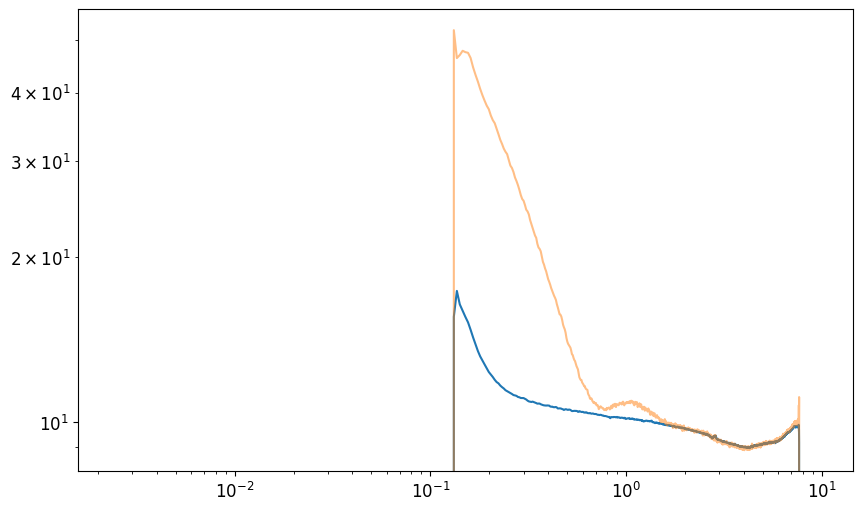

In [641]:
path = r"\\Synology\Data\2026\SC5781\RAW_DATA\Zalygin_solutions\Zalygin_solutions_PBS_Capill\SAXS\INT_q\Zalygin_solutions_PBS_Capill_SAXS_0000_av.dat"

data = pd.read_csv(path, sep='	', names=['q', 'I', 'err'], skiprows=1)
q = data['q']
I_PBS = data['I']
# df = pd.DataFrame({'q':q, 'I':I})

path = r'E:\Zalygin geles\5781\Zalygin_solutions_Liquid_112'
Exp = BM26_experiment(path)

q, I = Exp.get_1d_SAXS(5)

k = 1
plt.loglog(q, k * I_PBS)
plt.plot(q, I, alpha=0.5)
# plt.plot(q, I - k * I_PBS)

plt.ylim()

df = pd.DataFrame({'q':q/10, 'I':I - k * I_PBS})

df.to_csv(r'E:\Zalygin geles\5781\sample_112.txt', sep='\t', index=False)

C:\Users\LabPCA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


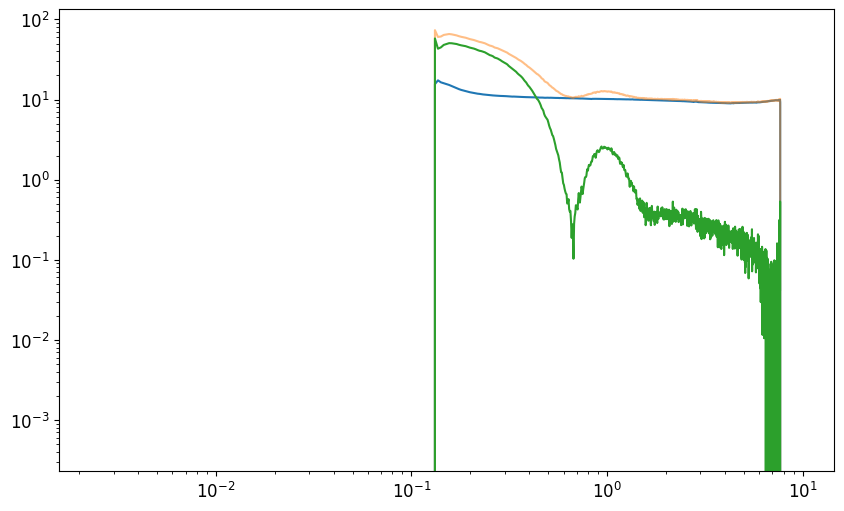

In [640]:
path = r"\\Synology\Data\2026\SC5781\RAW_DATA\Zalygin_solutions\Zalygin_solutions_PBS_Capill\SAXS\INT_q\Zalygin_solutions_PBS_Capill_SAXS_0000_av.dat"

data = pd.read_csv(path, sep='	', names=['q', 'I', 'err'], skiprows=1)
q = data['q']
I_PBS = data['I']

path = r'\\Synology\Data\2026\SC5781\RAW_DATA\Zalygin_solutions\Zalygin_solutions_Liquid_100'
Exp = BM26_experiment(path)

q, I = Exp.get_1d_SAXS(5)

k = 1.0
plt.loglog(q, k * I_PBS)
plt.plot(q, I, alpha=0.5)
plt.plot(q, I - k * I_PBS)

plt.ylim()

df = pd.DataFrame({'q':q/10, 'I':I - k * I_PBS, 'err':np.sqrt(I - k * I_PBS)})

df.to_csv(r'E:\Zalygin geles\5781\sample_100.txt', sep='\t', index=False)

# **Functions**

In [26]:
def sqrt(a):
    return np.sqrt(a)

## Hex structure

In [579]:
import numpy as np
from scipy.special import gamma, loggamma

def peak_shape(q, q0, delta, nu):
    """
    Форма пика из статьи Förster et al., уравнение (27).
    nu -> 0: Lorentzian, nu -> inf: Gaussian.
    """
    x = (q - q0) / delta  # нормированное расстояние
    y = 4 * x**2 / np.pi   # переменная для гамма-функции

    if nu < 0.01:
        # Явная Lorentzian (численно стабильно)
        return (1 / (np.pi * delta)) / (1 + 4 * x**2)
    
    elif nu > 100:
        # Явная Gaussian (предел)
        return (2 / (np.pi * delta)) * np.exp(-4 * x**2 / np.pi)
    
    else:
        # Общая формула через гамма-функции
        gamma_nu = np.sqrt(np.pi) * gamma((nu + 1) / 2) / gamma(nu / 2)
        
        # Используем loggamma для численной стабильности
        z = nu / 2 + 1j * gamma_nu * y
        log_abs = np.real(loggamma(z)) - np.real(loggamma(nu / 2))
        
        return (2 / (np.pi * delta)) * np.exp(2 * log_abs)

def hex_Sq(q, g, delta, nu, Delta, c=1.0):
    """
    Структурный фактор для гексагональной решетки цилиндров.
    По статье Freiberger & Glatter (2006), уравнение (35).
    """
    # Позиции и мультиплетности (достаточно первых 3-4 пиков для начала)
    peaks = np.array([
        [1, 0, 6],   # (10)
        [1, 1, 6],   # (11)
        [2, 0, 6],   # (20)
        [2, 1, 12],  # (21)
        [3, 0, 6],   # (30)
        [2, 2, 6],   # (22)
        [3, 1, 12],  # (31)
    ])

    # Позиции пиков для гексагональной решетки
    q0 = (4 * np.pi / (np.sqrt(3) * g)) * np.sqrt(
        peaks[:, 0]**2 + peaks[:, 0] * peaks[:, 1] + peaks[:, 1]**2
    )

    # Решеточный фактор Z0 (сумма пиков)
    Z0 = np.zeros_like(q)
    for idx, (h, k, m) in enumerate(peaks):
        L = peak_shape(q, q0[idx], delta, nu)
        Z0 += m * L

    # Множитель из уравнения (28)
    prefactor = c * 2 / (np.sqrt(3) * g**2 * (q + 1e-10))
    Z0 *= prefactor

    # Фактор Дебая-Валлера (затухание)
    G = np.exp(-Delta * q**2)

    # Полный структурный фактор
    return 1 + (Z0 - 1) * G

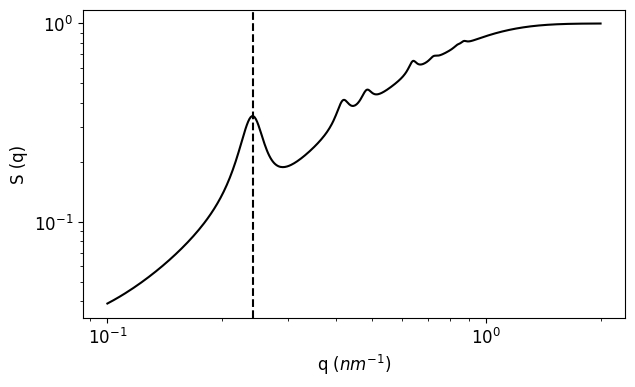

In [580]:
plt.figure(figsize=(7, 4))

x = np.linspace(0.1, 2, 1000)
g = 30
delta = 0.04
nu = 0
Delta = 2
c=1.0

plt.loglog(x, hex_Sq(x, g, delta, nu, Delta, c), color='black')
plt.xlabel('q ($nm^{-1}$)')
plt.ylabel('S (q)')

plt.axvline(x=4*pi/sqrt(3)/g, color='black', linestyle='--')

## FCC

In [476]:
import numpy as np
from scipy.special import gamma, loggamma

def peak_shape(q, q0, delta, nu):
    """
    Форма пика из статьи Förster et al., уравнение (27).
    nu -> 0: Lorentzian, nu -> inf: Gaussian.
    """
    x = (q - q0) / delta
    y = 4 * x**2 / np.pi

    if nu < 0.01:
        return (1 / (np.pi * delta)) / (1 + 4 * x**2)
    elif nu > 100:
        return (2 / (np.pi * delta)) * np.exp(-4 * x**2 / np.pi)
    else:
        gamma_nu = np.sqrt(np.pi) * gamma((nu + 1) / 2) / gamma(nu / 2)
        z = nu / 2 + 1j * gamma_nu * y
        log_abs = np.real(loggamma(z)) - np.real(loggamma(nu / 2))
        return (2 / (np.pi * delta)) * np.exp(2 * log_abs)


def fcc_Sq(q, a, delta, nu, Delta, c=1.0):
    """
    Структурный фактор для FCC решетки.
    
    Параметры:
    ----------
    q : array
        Переданный импульс (нм^-1)
    a : float
        Параметр решетки (нм)
    delta : float
        Ширина пика (нм^-1)
    nu : float
        Форма пика (0 -> Lorentzian, inf -> Gaussian)
    Delta : float
        Фактор затухания (нм^2)
    c : float
        Поправочный коэффициент
    """
    # Индексы: (h,k,l), m, f
    peaks = np.array([
        [1, 1, 1, 8, 4],   # (111)
        [2, 0, 0, 6, 4],   # (200)
        [2, 2, 0, 12, 4],  # (220)
        [3, 1, 1, 24, 4],  # (311)
        [2, 2, 2, 8, 4],   # (222)
        [4, 0, 0, 6, 4],   # (400)
        [3, 3, 1, 24, 4],  # (331)
    ])

    # Позиции пиков для FCC
    q0 = (2 * np.pi / a) * np.sqrt(peaks[:, 0]**2 + peaks[:, 1]**2 + peaks[:, 2]**2)

    # Решеточный фактор Z0
    Z0 = np.zeros_like(q)
    for idx, (h, k, l, m, f) in enumerate(peaks):
        L = peak_shape(q, q0[idx], delta, nu)
        Z0 += m * f * L

    # Множитель из уравнения для FCC
    # Z0(q) = c * (2π / a^3) * (1/q^2) * sum(m * f * L)
    prefactor = c * (2 * np.pi) / (a**3 * (q**2 + 1e-10))
    Z0 *= prefactor

    # Фактор Дебая-Валлера
    G = np.exp(-Delta * q**2)

    # Полный структурный фактор
    return 1 + (Z0 - 1) * G

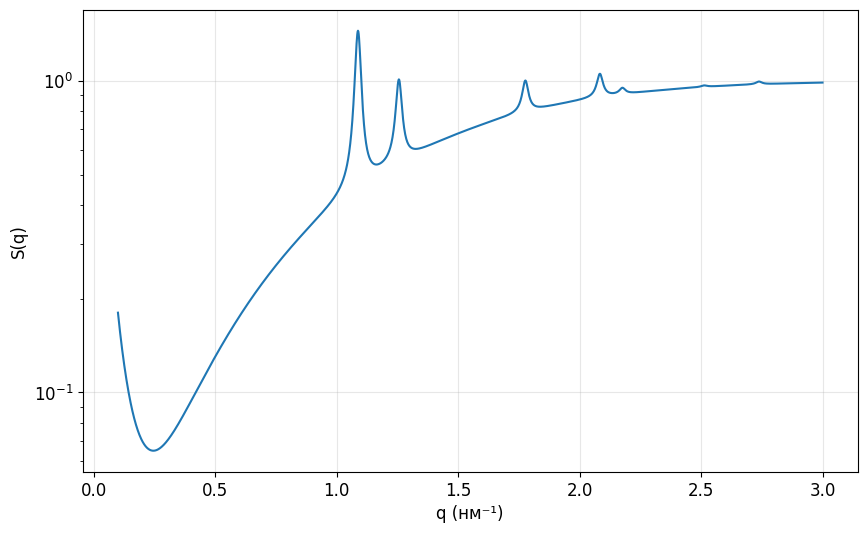

In [478]:
# Параметры
a = 10.0       # нм
delta = 0.03   # нм^-1
nu = 0.
Delta = 0.5    # нм^2
c = 1.0

q = np.linspace(0.1, 3.0, 2000)
S = fcc_Sq(q, a, delta, nu, Delta, c)

plt.plot(q, S)
plt.xlabel('q (нм⁻¹)')
plt.ylabel('S(q)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

## Cylinder FF

In [195]:
def cylinder_form_factor(q, R, scale=1.0, bg=0.0):
    """
    Форм-фактор длинного однородного цилиндра.
    
    q    : переданный импульс (нм⁻¹)
    R    : радиус цилиндра (нм)
    scale: масштаб
    bg   : фон
    """
    qR = q * R
    # Сечение: 2πR² * J₁(qR)/(qR)
    P_c = (2 * np.pi * R**2 * j1(qR) / (qR + 1e-10))**2
    # Полный форм-фактор: (1/q) * P_c
    P = P_c / (q + 1e-10)
    return scale * P + bg

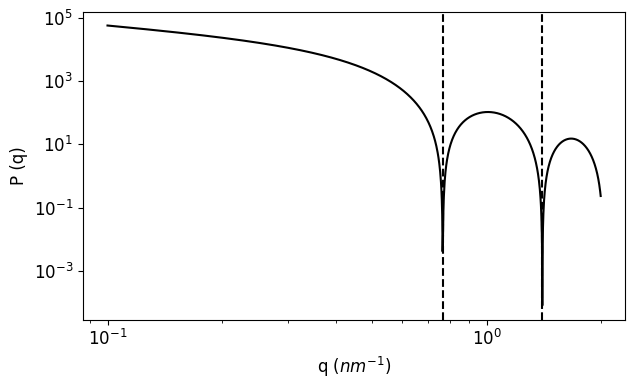

In [196]:
plt.figure(figsize=(7, 4))

x = np.linspace(0.1, 2, 1000)
R = 5

plt.loglog(x, cylinder_form_factor(x, R, 1, 0), color='black')
plt.xlabel('q ($nm^{-1}$)')
plt.ylabel('P (q)')

plt.axvline(x=3.83/R, color='black', linestyle='--')
plt.axvline(x=7.02/R, color='black', linestyle='--')


## Cylinder Core Shell FF

In [222]:
import numpy as np
from scipy.special import j1

def gaussian_weights(R_vals, R_bar, sigma):
    """Гауссовы веса для радиуса."""
    weights = np.exp(-(R_vals - R_bar)**2 / (2 * sigma**2))
    return weights / np.sum(weights)

def cylinder_core_shell(q, Rc, Rs, rhoc, rhos, scale=1, bkg=0):
    """Однородный core-shell (без полидисперсности)."""
    q_safe = q + 1e-10
    Fc = 2 * np.pi * Rc**2 * j1(q_safe * Rc) / (q_safe * Rc)
    Fs = 2 * np.pi * Rs**2 * j1(q_safe * Rs) / (q_safe * Rs)
    F = rhos * Fs + (rhoc - rhos) * Fc
    return scale * (np.abs(F)**2) / q_safe + bkg

def cylinder_core_shell_polydisperse(q, Rc, Rs, polydispersity, rhoc, rhos, scale=1, bkg=0, n_pts=20):
    """Core-shell цилиндр с гауссовой полидисперсностью."""
    sigma_R = polydispersity * Rs
    R_min = max(0.1, Rs - 3 * sigma_R)
    R_max = Rs + 3 * sigma_R
    R_vals = np.linspace(R_min, R_max, n_pts)
    weights = gaussian_weights(R_vals, Rs, sigma_R)
    
    # Усредняем |F|^2 (без 1/q!)
    F2_avg = np.zeros_like(q, dtype=float)
    for R, w in zip(R_vals, weights):
        Rc_scaled = Rc * (R / Rs)
        Fc = 2 * np.pi * Rc_scaled**2 * j1(q * Rc_scaled) / (q * Rc_scaled + 1e-10)
        Fs = 2 * np.pi * R**2 * j1(q * R) / (q * R + 1e-10)
        F = rhos * Fs + (rhoc - rhos) * Fc
        F2_avg += w * np.abs(F)**2
    
    # Лоренц-фактор применяем ПОСЛЕ усреднения
    return scale * F2_avg / (q + 1e-10) + bkg

Text(0, 0.5, 'P (q)')

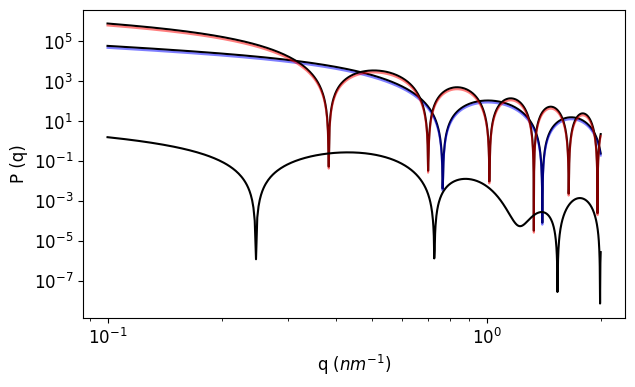

In [198]:
plt.figure(figsize=(7, 4))

x = np.linspace(0.1, 2, 1000)
R_core = 5
R_shell = 10
rho_core = -1
rho_shell = 1
scale = 1
bg = 0

# plt.loglog(x, cylinder_form_factor(x, R_core, scale, bg), color='b', linestyle='--')
# plt.loglog(x, cylinder_form_factor(x, R_shell, scale, bg), color='b', linestyle='--')


plt.loglog(x, cylinder_core_shell(x, R_core, R_shell, rho_core, 0, scale, bg), color='black')
plt.loglog(x, .8 * cylinder_form_factor(x, R_core, scale, bg), color='b', alpha=0.5)

plt.loglog(x, cylinder_core_shell(x, R_core, R_shell, rho_shell, rho_shell, scale, bg), color='black')
plt.loglog(x, .8 * cylinder_form_factor(x, R_shell, scale, bg), color='r', alpha=0.5)

plt.loglog(x, .00001 * cylinder_core_shell(x, R_core, R_shell, rho_core, rho_shell, scale, bg), color='black')


plt.xlabel('q ($nm^{-1}$)')
plt.ylabel('P (q)')



## Sphere FF

In [499]:
def sphere_amplitude(q, R):
    """
    Амплитуда однородной сферы радиуса R.
    F(q) = 4πR³ * [sin(qR) - qR*cos(qR)] / (qR)³
    """
    qR = q * R + 1e-10
    return 4 * np.pi * R**3 * (np.sin(qR) - qR * np.cos(qR)) / (qR**3)


def sphere_form_factor(q, R, scale=1.0, bg=0.0):
    """
    Форм-фактор однородной сферы.
    P(q) = |F(q)|²
    """
    F = sphere_amplitude(q, R)
    return scale * np.abs(F)**2 + bg


def sphere_core_shell(q, R_core, R_shell, rho_core, rho_shell, scale=1.0, bg=0.0):
    """
    Форм-фактор core-shell сферы.
    
    Параметры:
    ----------
    q : array
        Переданный импульс (нм^-1)
    R_core : float
        Радиус ядра (нм)
    R_shell : float
        Полный радиус (нм)
    rho_core : float
        Контраст ядра (относительно растворителя)
    rho_shell : float
        Контраст оболочки (относительно растворителя)
    scale : float
        Масштаб
    bg : float
        Фон
    """
    # Амплитуда ядра
    F_core = sphere_amplitude(q, R_core)
    
    # Амплитуда всей сферы (как если бы она была однородной)
    F_shell = sphere_amplitude(q, R_shell)
    
    # Амплитуда core-shell
    F = rho_core * F_core + rho_shell * (F_shell - F_core)
    
    # Интенсивность
    return scale * np.abs(F)**2 + bg


# **Data**

In [199]:
green = pd.read_csv(r"E:\Zalygin geles\SAXS gels\green.dat", sep=str('  '), 
                      skiprows=5, names=['q', 'I', 'err'], encoding='latin1')
red = pd.read_csv(r"E:\Zalygin geles\SAXS gels\red.dat", sep=str('  '), 
                      skiprows=5, names=['q', 'I', 'err'], encoding='latin1')

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_5316\2727612186.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  green = pd.read_csv(r"E:\Zalygin geles\SAXS gels\green.dat", sep=str('  '),
C:\Users\LabPCA\AppData\Local\Temp\ipykernel_5316\2727612186.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  red = pd.read_csv(r"E:\Zalygin geles\SAXS gels\red.dat", sep=str('  '),


# **Analysis**

## S(q) 

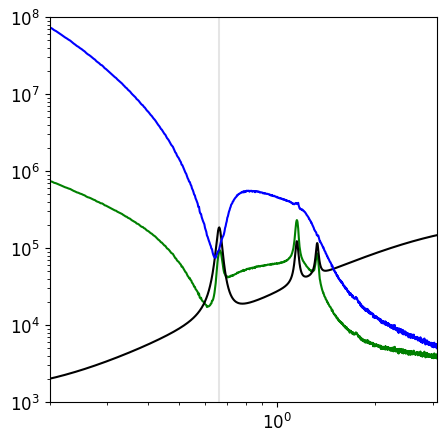

In [559]:
q = green['q']
I = green['I']

plt.figure(figsize=(5,5))
plt.loglog(q, I, color='g')

g = 10.94
delta = 0.03
nu = 0
Delta = 0.14
c = 1.0

plt.loglog(q, 2e5 * hex_Sq(q, g, delta, nu, Delta, c), color='black')
P_exp = I /  hex_Sq(q, g, delta, nu, Delta, c)

plt.loglog(q, P_exp, color='b')

plt.xlim(0.2, 3.1)
plt.ylim(1e3, 1e8)
plt.axvline(x=4 * pi / sqrt(3)/ 10.94, color='black', alpha=0.1)

In [560]:
4 * pi / sqrt(3)/ 10.94


np.float64(0.6631807547474289)

## Hankel

In [561]:
def pc_from_Pq(q, Pq, r_max, n_r=500):
    r = np.linspace(1e-6, r_max, n_r)
    Fq = Pq * q  # убираем лоренц-фактор
    pc = np.array([r_i * np.trapezoid(Fq * np.sin(q * r_i) / (q * r_i + 1e-10), q) for r_i in r])
    return r, pc


In [562]:
df = pd.DataFrame({'q':q, 'I':P_exp, 'sigma':sqrt(P_exp)})
df.to_csv(r'E:\Zalygin geles\P.txt', sep=str(' '), index=False)

In [563]:
def model(q, R_core, R_shell, rho_core, rho_shell, scale, bg):
    return cylinder_core_shell(q, R_core, R_shell, rho_core, rho_shell, scale, bg) / q

1.8903165786814307
4.513233973657465


array([ 1.89031658e+00,  4.51323397e+00, -7.04496033e-01,  1.10798503e+00,
        1.28804263e+03,  1.94345348e+04])

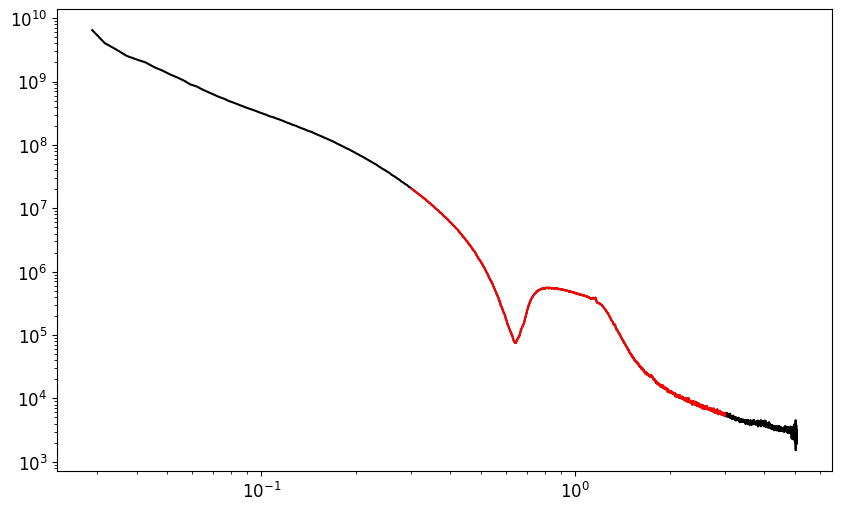

In [578]:
plt.loglog(q, P_exp, color='black')
l, r = 0.3, 3

x = q[(q>l)*(q<r)]
y = P_exp[(q>l)*(q<r)]
plt.plot(x, y, color='r')

R_core = 1
R_shell = 9.5 / 2
rho_core = -1
rho_shell = 1
scale = 5e2
bg = 1e4

# plt.loglog(q, cylinder_core_shell(q, R_core, R_shell, rho_core, rho_shell, scale, bg) / q)

# p, cov = curve_fit(model, x, y, p0=[R_core, R_shell, rho_core, rho_shell, scale, bg], sigma=y)

# plt.plot(x, model(x, *p))
print(p[0])
print(p[1])
p

In [565]:
2*pi/0

ZeroDivisionError: float division by zero

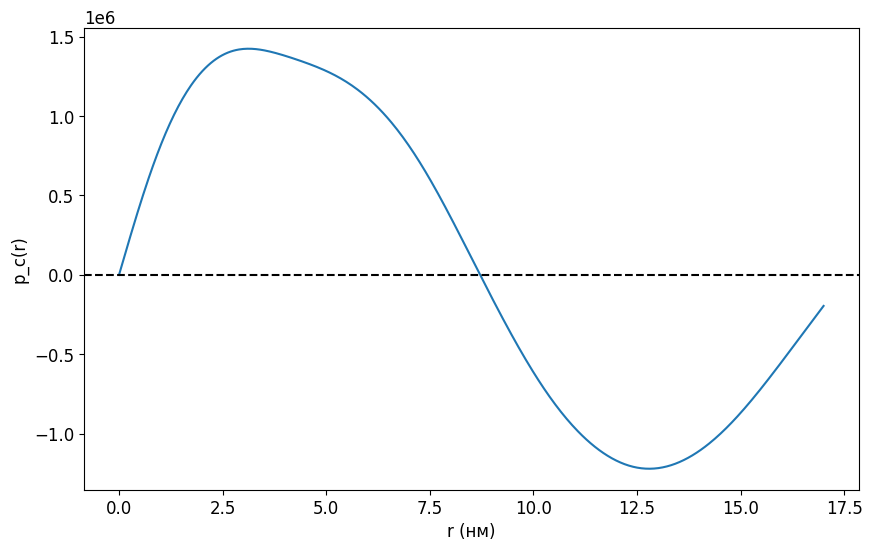

In [566]:
r, pc = pc_from_Pq(x, y, r_max=17.0)
plt.plot(r, pc)

plt.axhline(0, color='black', linestyle='--')
plt.xlabel('r (нм)')
plt.ylabel('p_c(r)')
plt.show()

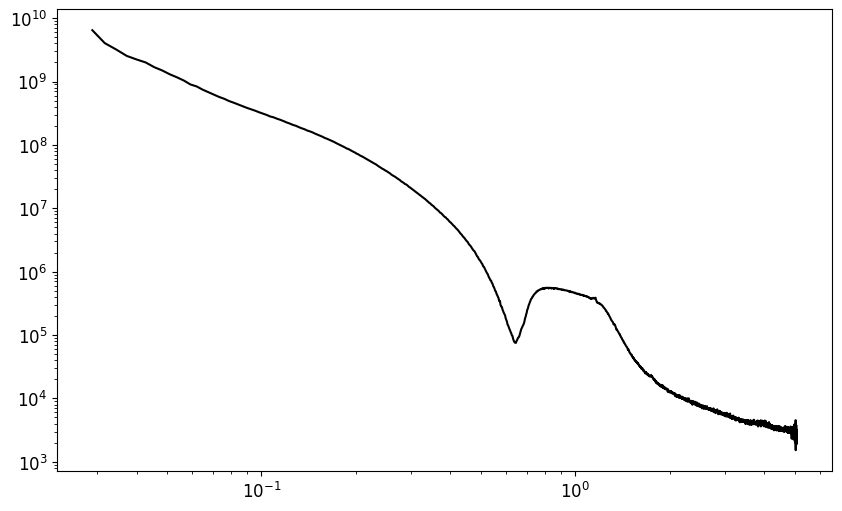

In [567]:
plt.loglog(q, P_exp, color='black')

# x = np.linspace(0.1, 2, 1000)
# R_core = 1.5
# R_shell = 5
# rho_core = -1
# rho_shell = 1
# scale = 1
# bg = 0

# plt.loglog(q, cylinder_core_shell(q, R_core, R_shell, rho_core, rho_shell, scale, bg), color='black', alpha=0.4)
# # cylinder_core_shell_polydisperse(q, Rc, Rs, polydispersity, rhoc, rhos, scale=1, bkg=0, n_pts=20)
# plt.loglog(q, cylinder_core_shell_polydisperse(q, R_core, R_shell, 0.1, rho_core, rho_shell, 1e3, 1e3), color='black')


## Electron density

In [568]:
def rho_profile(r, R_core, R_shell, rho_core, rho_shell, sigma):
    """
    Плавный профиль электронной плотности.
    """
    transition_core = 0.5 * (1 + erf((r - R_core) / (sigma * np.sqrt(2))))
    transition_shell = 0.5 * (1 + erf((r - R_shell) / (sigma * np.sqrt(2))))
    
    return rho_core * (1 - transition_core) + rho_shell * (transition_core - transition_shell)

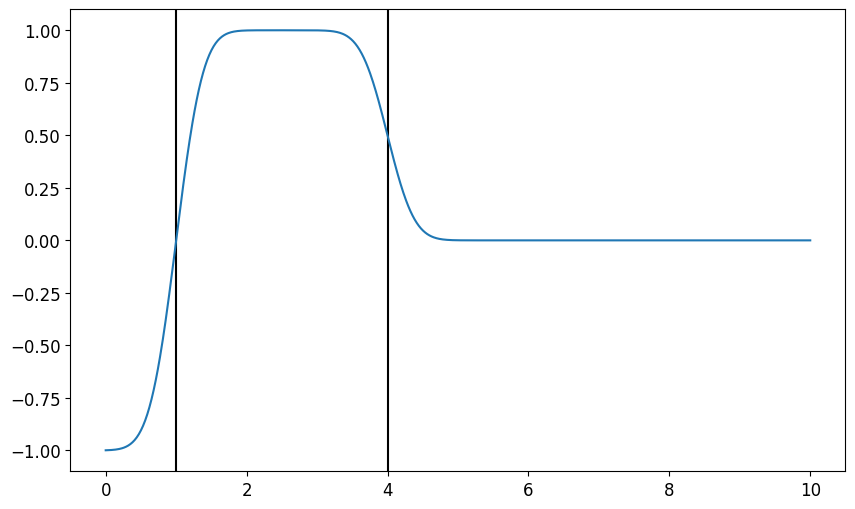

In [569]:
r = np.linspace(0, 10, 1000)
R_core = 1
R_shell = 4

rho = rho_profile(r, R_core=R_core, R_shell=R_shell, rho_core=-1, rho_shell=1, sigma=0.3)
plt.axvline(x=R_core, color='black')
plt.axvline(x=R_shell, color='black')

plt.plot(r, rho)

In [570]:
def form_factor_from_profile(q, R_core, R_shell, rho_core, rho_shell, sigma, scale=1.0, bg=0.0, n_r=500):
    """
    Расчёт форм-фактора цилиндра по профилю плотности.
    """
    # Радиальная сетка
    R_max = R_shell + 3 * sigma  # чтобы захватить весь переход
    r = np.linspace(0, R_max, n_r)
    dr = r[1] - r[0]
    
    # Профиль плотности
    rho = rho_profile(r, R_core, R_shell, rho_core, rho_shell, sigma)
    
    # Амплитуда для каждого q
    F = np.zeros_like(q, dtype=complex)
    for i, qi in enumerate(q):
        integrand = rho * j0(qi * r) * r
        F[i] = 2 * np.pi * simpson(integrand, r)
    
    # Форм-фактор с лоренц-фактором
    P = (np.abs(F)**2) / (q + 1e-10)
    
    return scale * P + bg


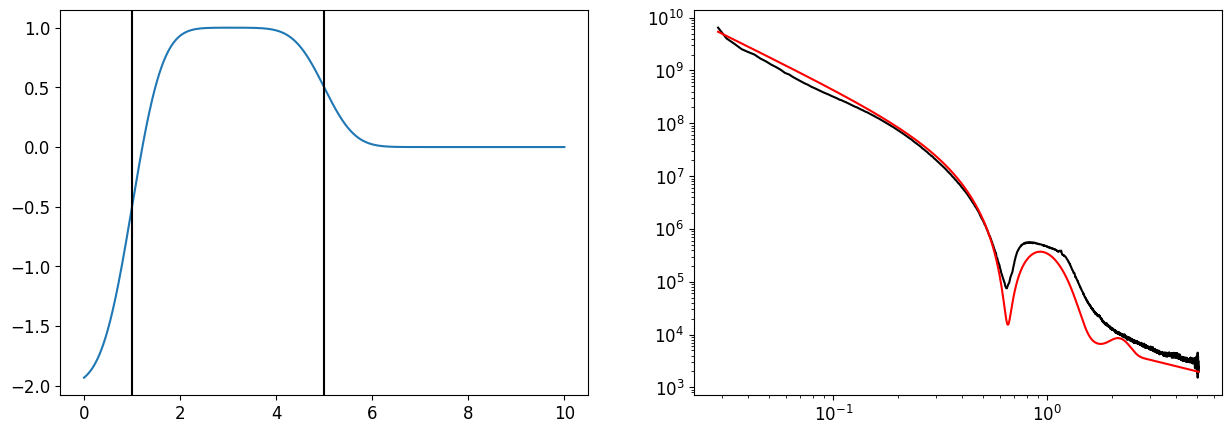

In [572]:
R_core = 1
R_shell = 10. / 2
rho_core = -2
rho_shell = 1.0
sigma = 0.5
scale = 1e3
bg = 1e4

# Расчёт
P_calc = form_factor_from_profile(q, R_core, R_shell, rho_core, rho_shell, sigma, scale, bg)

r = np.linspace(0, 10, 1000)
rho = rho_profile(r, R_core, R_shell, rho_core, rho_shell, sigma)


fig, ax = plt.subplots(1,2, figsize=(15, 5))
ax[0].plot(r, rho)
ax[0].axvline(x=R_core, color='black')
ax[0].axvline(x=R_shell, color='black')

ax[1].loglog(q, P_exp, color='black')
ax[1].loglog(q, P_calc / q, 'r-')

l, r = 0.3, 4

x = q[(q>l)*(q<r)]
y = P_exp[(q>l)*(q<r)]
# plt.scatter(x, y, color='blue', s=10)

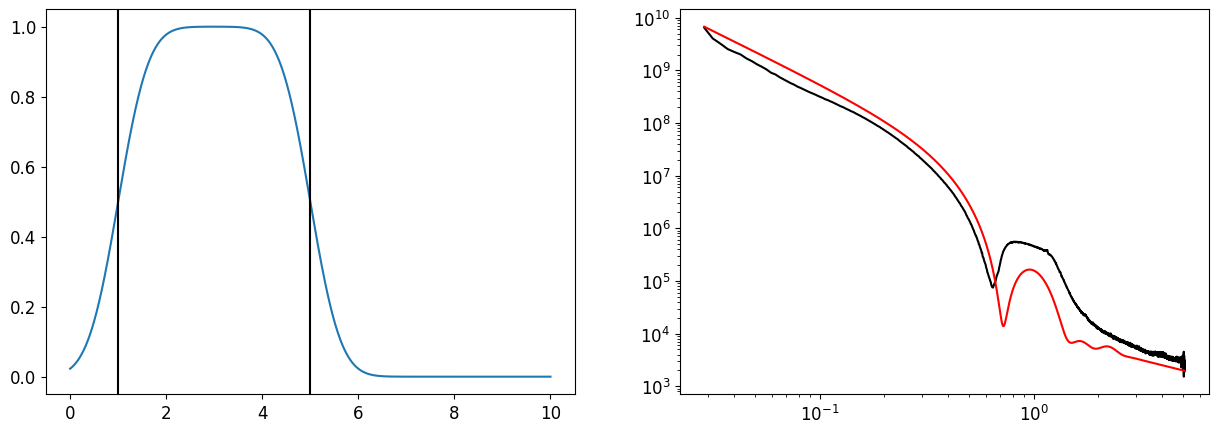

In [576]:
R_core = 1
R_shell = 10. / 2
rho_core = 0
rho_shell = 1.0
sigma = 0.5
scale = 1e3
bg = 1e4

# Расчёт
P_calc = form_factor_from_profile(q, R_core, R_shell, rho_core, rho_shell, sigma, scale, bg)

r = np.linspace(0, 10, 1000)
rho = rho_profile(r, R_core, R_shell, rho_core, rho_shell, sigma)


fig, ax = plt.subplots(1,2, figsize=(15, 5))
ax[0].plot(r, rho)
ax[0].axvline(x=R_core, color='black')
ax[0].axvline(x=R_shell, color='black')

ax[1].loglog(q, P_exp, color='black')
ax[1].loglog(q, P_calc / q, 'r-')

l, r = 0.3, 4

x = q[(q>l)*(q<r)]
y = P_exp[(q>l)*(q<r)]
# plt.scatter(x, y, color='blue', s=10)

# **Red**

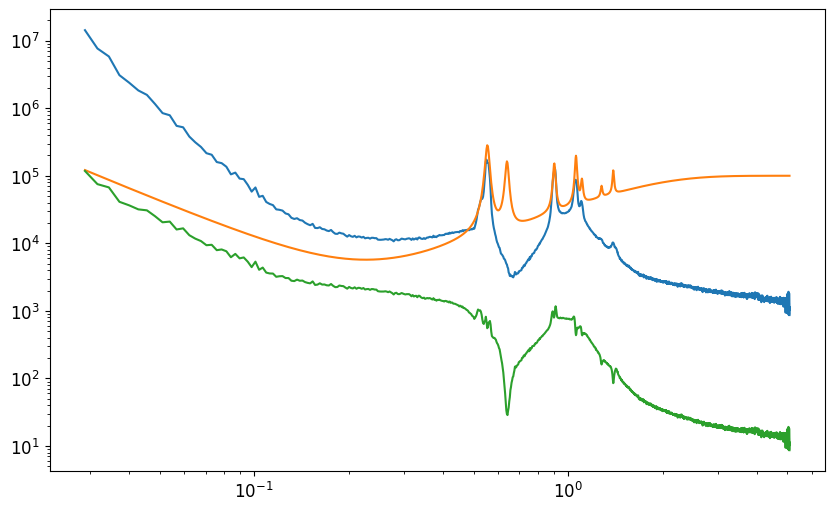

In [552]:
q = red['q']
I = red['I']

plt.loglog(q, I)

# Параметры
a = 19.66       # нм
delta = 0.018   # нм^-1
nu = 0.00
Delta = 0.4    # нм^2
c = 2

S = fcc_Sq(q, a, delta, nu, Delta, c)

plt.loglog(q, S * 1e5)
plt.loglog(q, I / S / 1e2 )

P_exp = I / S

In [544]:
def sphere_core_shell_polydisperse(q, R_core, R_shell, polydispersity, rho_core, rho_shell, scale=1.0, bg=0.0, n_pts=20):
    """
    Core-shell сфера с гауссовой полидисперсностью по радиусу.
    
    Параметры:
    ----------
    polydispersity : float
        Относительная полидисперсность (например, 0.1 = 10%)
    """
    sigma_R = polydispersity * R_shell
    R_min = max(0.1, R_shell - 3 * sigma_R)
    R_max = R_shell + 3 * sigma_R
    R_vals = np.linspace(R_min, R_max, n_pts)
    
    # Гауссовы веса
    weights = np.exp(-(R_vals - R_shell)**2 / (2 * sigma_R**2))
    weights /= np.sum(weights)
    
    # Усреднение
    P_avg = np.zeros_like(q)
    for R, w in zip(R_vals, weights):
        R_core_scaled = R_core * (R / R_shell)
        P = sphere_core_shell(q, R_core_scaled, R, rho_core, rho_shell, scale=1.0, bg=0.0)
        P_avg += w * P
    
    return scale * P_avg + bg

(100.0, 10000000.0)

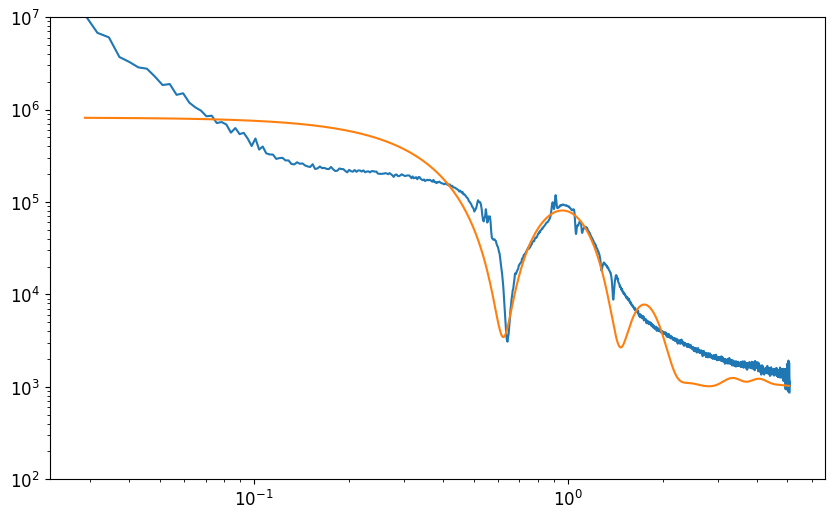

In [546]:
plt.loglog(q, P_exp)

R_core = 3
R_shell = 5.3
rho_core = -1 
rho_shell = 1
plt.loglog(q, sphere_core_shell_polydisperse(q, R_core, R_shell, 0.05, rho_core, rho_shell, scale=5.0, bg=1e3))
plt.ylim(1e2, 1e7)